<a href="https://colab.research.google.com/github/estefania-apaza/inferencia-causal-proyecto-lengua-enaho2024/blob/main/Actividad%202/TC2_Salinas_Apaza_Perez_Marcos_20231724_20230487_20212237_20221214.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Calificada 2


**Efecto de tener una lengua materna indígena en la confianza hacia la Policía Nacional**

Base de datos: Encuesta Nacional de Hogares 2024

X: Lengua materna indígena

Y: Nivel de confianza en la Policía

Enlace del repositorio de GitHub: https://github.com/estefania-apaza/inferencia-causal-proyecto-lengua-enaho2024/tree/main



*   20231724 - Adrian Salinas Alcántara
*   20230487 - Estefanía Apaza Díaz
*   20212237 - Maria Jesus Perez Zarate
*   20221214 - Fabiana Marcos




## Preparación de la base de datos



In [ ]:
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Cargamos la base modificada en la TC1

# URL "raw" del archivo CSV en GitHub
url = "https://raw.githubusercontent.com/estefania-apaza/inferencia-causal-proyecto-lengua-enaho2024/refs/heads/main/Actividad%202/enaho_limpia_t1.csv"

# Cargar el CSV
data = pd.read_csv(url, encoding="latin-1")

data.head(2)
data.columns

Index(['conglome', 'vivienda', 'hogar', 'codperso', 'p208a', 'p207', 'p300a',
       'p301a', 'p1$06', 'estrsocial', 'dominio', 'dom_2', 'dom_3', 'dom_4',
       'dom_5', 'dom_6', 'dom_7', 'dom_8', 'estrsoc_2.0', 'estrsoc_3.0',
       'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0', 'educ_2.0', 'educ_3.0',
       'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0',
       'educ_11.0', 'educ_12.0', 'lengua_indigena', 'conf_policia'],
      dtype='object')

**La base cargada fue preparada para la Tarea Calificada 1**. Se presenta una descripción:

Variable independiente: lengua_indigena

```
0: No habla lengua indígena
1: Habla lengua indígena
```

Variable dependiente: conf_policia

```
# Ya se han eliminado los NN
1. Nada
2. Poco
3. Suficiente
4. Bastante
```

Variables de control:

*   p208a: edad (en números)
*   p207: sexo
```
1. Hombre
2. Mujer
```
*   dom_*
```
# Dummies basadas en los siguientes valores:
1.Costa Norte
2.Costa Centro
3.Costa Sur
4.Sierra Norte
5.Sierra Centro
6.Sierra Sur
7.Selva
8.Lima Metropolitana
```

*   estrsoc_*

```
# Dummies basadas en los siguientes valores:
1.A
2.B
3.C
4.D
5.E
6. Rural
```

*   educ_*

```
# Dummies basadas en la pregunta: ¿Cuál es el último año o grado de estudios y nivel que aprobó?
```

**Sobre esta base se trabajará a continuación.**

In [ ]:
# Revisamos que todas las variables sean numéricas
# Solo colocamos dos dummies de cada uno como ejemplo

variables = ['p208a', 'p207','p301a','educ_4.0','educ_5.0','lengua_indigena','conf_policia','dom_5', 'dom_6','estrsoc_2.0', 'estrsoc_3.0']

data[variables].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5046 entries, 0 to 5045
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   p208a            5046 non-null   int64  
 1   p207             5046 non-null   int64  
 2   p301a            5046 non-null   float64
 3   educ_4.0         5046 non-null   int64  
 4   educ_5.0         5046 non-null   int64  
 5   lengua_indigena  5046 non-null   int64  
 6   conf_policia     5046 non-null   float64
 7   dom_5            5046 non-null   int64  
 8   dom_6            5046 non-null   int64  
 9   estrsoc_2.0      5046 non-null   int64  
 10  estrsoc_3.0      5046 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 433.8 KB


In [ ]:
# Evaluamos la mediana de conf_policia para crear la variable dicotómica
mediana = data['conf_policia'].median()
print("Mediana de conf_policia:", mediana)

Mediana de conf_policia: 2.0


In [ ]:
# Creamos la variable dicotómica usando la mediana
data['conf_policia_dic'] = (data['conf_policia'] > data['conf_policia'].median()).astype(int)

# Revisamos distribución
data['conf_policia_dic'].value_counts()

,count
conf_policia_dic,
0,4065
1,981


In [ ]:
# Cambiamos nombres de variables para facilitar el tratamiento

data = data.rename(columns={
    'p208a': 'edad',
    'p207': 'sexo',})

# Filtramos la data por las columnas a usar

cols_usar = ['edad', 'sexo',
             'dom_2', 'dom_3', 'dom_4', 'dom_5', 'dom_6', 'dom_7', 'dom_8',
             'estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0',
             'educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0',
             'lengua_indigena', 'conf_policia_dic', 'conf_policia']

data = data[cols_usar].copy()

In [ ]:
# Revisamos la data final para confirmar que las variables estan listas para el análisis
data.head(3)

,edad,sexo,dom_2,dom_3,dom_4,dom_5,dom_6,dom_7,dom_8,estrsoc_2.0,...,educ_5.0,educ_6.0,educ_7.0,educ_8.0,educ_10.0,educ_11.0,educ_12.0,lengua_indigena,conf_policia_dic,conf_policia
0,65,1,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1.0
1,33,2,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2.0
2,58,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2.0


## Modelos de Regresión (MCO)
**Regresiones**


*   Modelo 1: Simple
*   Modelo 2: Múltiple



In [ ]:
# ==============================================================================
# MODELO BASE (MCO)
# ==============================================================================

# Transformación de variables
# Volvemos a crear una variable dummy "mujer" (0=Hombre, 1=Mujer) para facilitar interpretación
data['mujer'] = data['sexo'].map({1: 0, 2: 1})

# Definimos VD
y = data['conf_policia']

# Agrupamos variables de control (omitiremos la categoría base para evitar colinealidad)
controles_educ = ['educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0']
controles_estrato = ['estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0']

# Definimos las VI para cada modelo
X_simple = data[['lengua_indigena']]
X_multiple = data[['lengua_indigena', 'edad', 'mujer'] + controles_educ + controles_estrato]

# Agregaremos la constante en statsmodels
X_simple = sm.add_constant(X_simple)
X_multiple = sm.add_constant(X_multiple)

#  Regresión 1 (Simple)
print("=================== REGRESIÓN 1: MODELO SIMPLE ===================")
modelo_1 = sm.OLS(y, X_simple).fit()
print(modelo_1.summary())

# Regresión 2 (con controles)
print("\n=================== REGRESIÓN 2: MODELO MÚLTIPLE ===================")
modelo_2 = sm.OLS(y, X_multiple).fit()
print(modelo_2.summary())

=================== REGRESIÓN 1: MODELO SIMPLE ===================
                            OLS Regression Results                            
Dep. Variable:           conf_policia   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     82.29
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.65e-19
Time:                        04:32:21   Log-Likelihood:                -6181.3
No. Observations:                5046   AIC:                         1.237e+04
Df Residuals:                    5044   BIC:                         1.238e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [ ]:
# ==============================================================================
# Diagnósticos (Sobre modelo múltiple) Y selección
# ==============================================================================

# Test de multicolinealidad (VIF)
print("--- Factor de inflación de varianza (VIF) ---")
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multiple.columns
# Calculamos el VIF iterando por cada columna
vif_data["VIF"] = [variance_inflation_factor(X_multiple.values, i) for i in range(X_multiple.shape[1])]
print(vif_data)
# Si VIF > 10 indica problemas de multicolinealidad

# Test de heterocedasticidad (White)
print("\n--- Prueba de White de Heterocedasticidad ---")
residuos = modelo_2.resid
white_test = het_white(residuos, X_multiple)
print(f"Estadístico LM: {white_test[0]:.4f}")
print(f"p-value LM: {white_test[1]:.4f}")
# Si el p-value es menor a 0.05, existe heterocedasticidad en el modelo

# C. Comparación de criterios (selección)
print("\n--- SELECCIÓN DE MODELOS (Criterios AIC y BIC) ---")
print("Regla: Valores más bajos indican un mejor modelo.")
print(f"Modelo 1 (Simple)   -> AIC: {modelo_1.aic:.2f}  |  BIC: {modelo_1.bic:.2f}")
print(f"Modelo 2 (Múltiple) -> AIC: {modelo_2.aic:.2f}  |  BIC: {modelo_2.bic:.2f}")

--- Factor de inflación de varianza (VIF) ---
           Variable         VIF
0             const  124.037861
1   lengua_indigena    1.159673
2              edad    1.352906
3             mujer    1.052000
4          educ_2.0    1.007724
5          educ_3.0    3.489683
6          educ_4.0    3.276218
7          educ_5.0    2.978121
8          educ_6.0    5.310972
9          educ_7.0    2.268920
10         educ_8.0    3.067803
11        educ_10.0    2.933594
12        educ_11.0    1.388040
13        educ_12.0    1.007938
14      estrsoc_2.0    3.060427
15      estrsoc_3.0    6.362374
16      estrsoc_4.0   11.263736
17      estrsoc_5.0   15.844920
18      estrsoc_6.0   18.235744

--- Prueba de White de Heterocedasticidad ---
Estadístico LM: 118.5814
p-value LM: 0.0991

--- SELECCIÓN DE MODELOS (Criterios AIC y BIC) ---
Regla: Valores más bajos indican un mejor modelo.
Modelo 1 (Simple)   -> AIC: 12366.63  |  BIC: 12379.68
Modelo 2 (Múltiple) -> AIC: 12336.32  |  BIC: 12460.32


**Interpretación**

En primer lugar, en cuanto la selección de modelos, al comparar ambos modelos, se observan resultados mixtos. El Modelo 2 (Múltiple) presenta un AIC de 12336.32, el cual es menor que el del Modelo 1 (12366.63), lo que indica un mejor ajuste. Sin embargo, su BIC es de 12460.32, que es mayor al del Modelo 1 (12379.68). Esta discrepancia ocurre porque el BIC penaliza de forma mucho más estricta la inclusión de muchas variables explicativas (todas las dummies de educación y estrato).


En este marco, elegimos el Modelo 2 como el principal, ya que el AIC respalda su ajuste y teóricamente necesitamos controlar por estas variables socioeconómicas para aislar el efecto real de la lengua indígena y evitar sesgos por variable omitida.

Asimismo, en cuanto a la variable lengua_indigena, nos enfocamos en el coeficiente de regresión parcial para nuestra variable de tratamiento, observando el resultado del Modelo 2. Manteniendo constantes todos los demás factores (edad, el sexo, el nivel educativo y el estrato social), tener como lengua materna una lengua indígena está asociado con una reducción promedio de 0.2256 puntos en la probabilidad de confiar en la Policía nacional. Al observar su valor p (P>|t| = 0.000), notamos que es netamente menor a 0.05, lo que significa que este efecto negativo es estadísticamente muy significativo.


En cuanto al VIF, nuestra variable de tratamiento (lengua_indigena = 1.15) y la mayoría de variables de control están por debajo del valor crítico de 10, lo que sugiere que no tenemos problemas de colinealidad con nuestra variable de interés. Sin embargo, las dummies de estrato social alto (estrsoc_4.0, estrsoc_5.0 y estrsoc_6.0) presentan VIFs superiores a 10 (llegando hasta 18.2). Esto indica que existe multicolinealidad entre los niveles de estratificación social, lo cual es esperable en este tipo de encuestas, pero no afecta de manera importante la precisión del coeficiente de nuestra variable principal (lengua indígena), cuyo VIF se mantiene en niveles bajos.

Por otro lado, en la prueba de White, obtuvimos un valor p de 0.0991. Al ser mayor a 0.05, no rechazamos la hipótesis nula de homocedasticidad. Esto es un excelente resultado, ya que indica que la varianza de los errores es constante en el modelo. Al no detectar un problema significativo de heterocedasticidad, los errores estándar clásicos reportados por nuestro modelo MCO son válidos y confiables.


## Análisis de heterogeneidad

Se implementan análisis por **sexo** y por vivenda en **zona rural**.

### Por sexo

**Modelo para mujeres**

In [ ]:
# Modelo de regresión lineal múltiple | MUJERES

# Filtrar mujeres (mujer == 2))
data_women = data[data['sexo'] == 2]
# Definir las variables
y_women = data_women['conf_policia_dic']
X_women = data_women[['lengua_indigena', 'edad','dom_2', 'dom_3', 'dom_4', 'dom_5', 'dom_6', 'dom_7', 'dom_8','estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0', 'educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0']]
# Constante para el intercepto
X_women = sm.add_constant(X_women)

# Modelo de regresión para mujeres:
model_women = sm.OLS(y_women, X_women).fit()
print(model_women.summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     4.850
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.20e-14
Time:                        04:32:22   Log-Likelihood:                -1333.9
No. Observations:                2809   AIC:                             2718.
Df Residuals:                    2784   BIC:                             2866.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3460      0.085     

In [ ]:
# Errores robustos
print(model_women.get_robustcov_results(cov_type='HC3').summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     6.200
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.23e-19
Time:                        04:32:22   Log-Likelihood:                -1333.9
No. Observations:                2809   AIC:                             2718.
Df Residuals:                    2784   BIC:                             2866.
Df Model:                          24                                         
Covariance Type:                  HC3                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3460      0.087     

Interpretación:

El modelo de regresión estimado para el subgrupo de mujeres muestra que la variable lengua indígena está asociada de manera negativa y estadísticamente significativa con la confianza en la policía. Hablar una lengua indígena se asocia con una reducción promedio de 0.066 puntos en la probabilidad de confiar en la policía, manteniendo constantes las demás variables de control (p < 0.01).

Este resultado sugiere que, entre las mujeres, aquellas cuya lengua materna es indígena presentan menores niveles de confianza en la policía en comparación con quienes no la tienen como lengua materna.

Asimismo, la edad presenta un efecto negativo y estadísticamente significativo (p < 0.05), indicando que, dentro del grupo de mujeres, la confianza en la policía tiende a disminuir ligeramente a medida que aumenta la edad.

Aunque el modelo es globalmente significativo (Prob > F < 0.01), el R² (0.040) indica que las variables incluidas explican una proporción limitada de la variación en la confianza en la policía.

**Modelo para hombres**

In [ ]:
# Modelo de regresión lineal múltiple | HOMBRES
# Filtrar hombres (hombre == 1))
data_men = data[data['sexo'] == 1]
# Definir las variables
y_men = data_men['conf_policia_dic']
X_men = data_men[['lengua_indigena', 'edad','dom_2', 'dom_3', 'dom_4', 'dom_5', 'dom_6', 'dom_7', 'dom_8','estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0', 'educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0']]
# Constante para el intercepto
X_men = sm.add_constant(X_men)

# Modelo de regresión para hombres:
model_men = sm.OLS(y_men, X_men).fit()
print(model_men.summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.444
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           0.000152
Time:                        04:32:22   Log-Likelihood:                -1062.8
No. Observations:                2237   AIC:                             2174.
Df Residuals:                    2213   BIC:                             2311.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0276      0.101     

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


Interpretación:

El modelo de regresión estimado únicamente para hombres muestra que el ajuste general es bajo (R² = 0.025), lo que indica que las variables incluidas explican alrededor del 2.5% de la variación en la confianza hacia la Policía. Sin embargo, el modelo es estadísticamente significativo en su conjunto (Prob > F = 0.000152).

El coeficiente asociado a lengua_indigena es negativo (-0.051) y estadísticamente significativo al 5% (p = 0.030). Esto indica que, entre los hombres, tener una lengua materna indígena está asociado con una menor probabilidad de presentar altos niveles de confianza en la Policía Nacional, manteniendo constantes las demás variables del modelo. Los hombres con lengua indígena presentan aproximadamente 5.1 puntos porcentuales menos de probabilidad de ubicarse por encima de la mediana de confianza respecto a quienes no tienen lengua indígena como lengua materna.

### Rural

In [ ]:
# Modelo de regresión lineal múltiple | RURAL
# Filtrar
data_rural = data[data['estrsoc_6.0'] == 1]
# Definir las variables
y_rural = data_rural['conf_policia_dic']
X_rural = data_rural[['lengua_indigena', 'edad','dom_2', 'dom_3', 'dom_4', 'dom_5', 'dom_6', 'dom_7', 'dom_8','estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0', 'educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0']]
# Constante para el intercepto
X_rural = sm.add_constant(X_rural)

# Modelo de regresión para Rural:
model_rural = sm.OLS(y_rural, X_rural).fit()
print(model_rural.summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.894
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           6.32e-08
Time:                        04:32:22   Log-Likelihood:                -965.76
No. Observations:                1964   AIC:                             1970.
Df Residuals:                    1945   BIC:                             2076.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
lengua_indigena    -0.0648      0.024     

In [ ]:
# Errores robustos
print(model_rural.get_robustcov_results(cov_type='HC3').summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     4.025
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.60e-08
Time:                        04:32:22   Log-Likelihood:                -965.76
No. Observations:                1964   AIC:                             1970.
Df Residuals:                    1945   BIC:                             2076.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
lengua_indigena    -0.0648      0.024     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 18
  warnings.warn('covariance of constraints does not have full '


Interpretación:

El modelo estimado para individuos con estrato socioeconómico "rural" presenta un bajo nivel de ajuste (R² = 0.035), lo que indica que las variables incluidas explican aproximadamente el 3.5% de la variación en la confianza hacia la Policía. No obstante, el modelo es estadísticamente significativo en su conjunto (p < 0.01).

El coeficiente asociado a lengua_indigena es negativo (-0.0648) y estadísticamente significativo (p = 0.006). Esto implica que, entre quienes tienen estrato socioeconómico rural, tener una lengua materna indígena está asociado con una menor probabilidad de presentar altos niveles de confianza en la Policía Nacional, manteniendo constantes las demás variables incluidas en el modelo. Los individuos rurales con lengua indígena presentan aproximadamente 6.5 puntos porcentuales menos de probabilidad de ubicarse por encima del nivel medio de confianza en comparación con quienes no tienen lengua indígena como lengua materna.

## Uso de variables cuadráticas

In [ ]:
# Modelo de regresión lineal múltiple | EDAD
data['edad_cuadr'] = data['edad'] ** 2

# Variables
y = data['conf_policia_dic']
X = data[['lengua_indigena', 'edad', 'edad_cuadr', 'sexo','estrsoc_6.0']]

# Constante
X = sm.add_constant(X)

# Modelo
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     21.51
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.31e-21
Time:                        04:32:22   Log-Likelihood:                -2429.1
No. Observations:                5046   AIC:                             4870.
Df Residuals:                    5040   BIC:                             4909.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4144      0.045     

In [ ]:
# Test F conjunto edad y edad cuadrado
hypothesis = 'edad = 0, edad_cuadr = 0'

f_test_result = model.f_test(hypothesis)

print(f_test_result)

<F test: F=14.50844506091056, p=5.213523137150712e-07, df_denom=5.04e+03, df_num=2>


In [ ]:
f_test_pvalue = f_test_result.pvalue
formatted_pvalue = f"{f_test_pvalue:.3f}"
print(f"F test p-value (3 decimales): {formatted_pvalue}")

F test p-value (3 decimales): 0.000


Interpretación:

Se estimó un modelo de regresión lineal incorporando un término cuadrático de la edad con el objetivo de evaluar si la relación entre edad y confianza en la Policía presenta un comportamiento no lineal. El modelo muestra un ajuste bajo (R² = 0.021), pero es estadísticamente significativo en su conjunto (p < 0.01).

El coeficiente de edad es negativo y estadísticamente significativo (β = −0.0085; p < 0.01); mientras que el coeficiente de edad² es positivo y estadísticamente significativo (β = 0.0000736; p < 0.01). Esto indica que la relación entre edad y confianza en la Policía no es lineal, sino que sigue una forma en U.

Esto sugiere que, a medida que aumenta la edad, la confianza en la Policía inicialmente disminuye; sin embargo, a edades más avanzadas esta tendencia se revierte y la confianza comienza a incrementarse nuevamente. En otras palabras, los individuos jóvenes y de mediana edad tienden a mostrar menores niveles de confianza, mientras que los adultos mayores suelen recuperar esta confianza.

Además, se realizó un Test F para evaluar la significancia conjunta de los términos edad y edad cuadrada. Dado que el p-value es prácticamente cero, se rechaza la hipótesis nula de que ambos coeficientes sean simultáneamente iguales a cero. Esto confirma que la inclusión del término cuadrático mejora significativamente la explicación del modelo, lo que evidencia que el efecto de la edad sobre la confianza policial es efectivamente no lineal.

## Significancia de interacciones

*   Ser mujer y hablar una lengua indígena
*   Vivir en una zona rural y hablar una lengua indígena



In [ ]:
# Crear interacción | MUJER Y LENGUA INDÍGENA
data['mujer'] = (data['sexo'] == 2).astype(int)
data['lengua_mujer'] = data['lengua_indigena'] * data['mujer']

In [ ]:
data['edad_cuadr'] = data['edad'] ** 2
# Variables
y = data['conf_policia_dic']
X = data[['lengua_indigena', 'mujer', 'lengua_mujer', 'edad', 'edad_cuadr', 'estrsoc_6.0']]

# Constante
X = sm.add_constant(X)

# Modelo
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     18.18
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.47e-21
Time:                        04:32:23   Log-Likelihood:                -2428.4
No. Observations:                5046   AIC:                             4871.
Df Residuals:                    5039   BIC:                             4916.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4142      0.042     

In [ ]:
f_test_result = model.f_test(
    ['lengua_indigena = 0', 'mujer = 0', 'lengua_mujer = 0']
)

print(f"F statistic: {f_test_result.fvalue:.3f}")

F statistic: 22.952


In [ ]:
print(f"p-value: {f_test_result.pvalue:.3f}")

p-value: 0.000


Interpretación:

Con el objetivo de evaluar si el efecto de tener una lengua materna indígena sobre la confianza en la Policía varía según el género, se incorporó un término de interacción entre lengua_indigena y mujer.

El término de interacción (lengua_mujer) no resulta estadísticamente significativo:

β = −0.0308

p = 0.218

Esto significa que no existe evidencia estadística suficiente para afirmar que el efecto negativo de tener lengua indígena sobre la confianza en la Policía sea diferente entre hombres y mujeres.

En otras palabras, aunque el efecto parece ligeramente más negativo para mujeres, la diferencia no es lo suficientemente grande como para descartarse que se deba al azar.

A partir del Test F, se rechaza la hipótesis nula conjunta, indicando que el conjunto de variables relacionadas con género y lengua indígena contribuye significativamente al modelo. Sin embargo, esto no implica que la interacción en sí misma sea significativa individualmente.

In [ ]:
# Crear interacción | RURAL Y LENGUA INDÍGENA
data['rural'] = (data['estrsoc_6.0'] == 1).astype(int)
data['lengua_rural'] = data['lengua_indigena'] * data['rural']

In [ ]:
data['edad_cuadr'] = data['edad'] ** 2
# Variables
y = data['conf_policia_dic']
X = data[['lengua_indigena','rural','lengua_rural','edad','edad_cuadr']]

# Constante
X = sm.add_constant(X)

# Modelo
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       conf_policia_dic   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     21.65
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.64e-21
Time:                        04:32:23   Log-Likelihood:                -2428.8
No. Observations:                5046   AIC:                             4870.
Df Residuals:                    5040   BIC:                             4909.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4195      0.042     

In [ ]:
f_test_result = model.f_test(
    "lengua_indigena = 0, rural = 0, lengua_rural = 0"
)

print(f"F statistic: {f_test_result.fvalue:.3f}")
print(f"p-value: {f_test_result.pvalue:.3f}")

F statistic: 23.734
p-value: 0.000


Interpretación:

El modelo incorpora una interacción entre lengua indígena y pertenencia al estrato socioeconómico rural. Los resultados muestran que el coeficiente asociado a lengua indígena es negativo y estadísticamente significativo (p < 0.01), lo que indica que, entre quienes no pertenecen al estrato rural, hablar una lengua indígena se asocia con una menor probabilidad de confiar en la policía. Por su parte, pertenecer al estrato socioeconómico rural presenta un efecto positivo y significativo, sugiriendo mayores niveles de confianza en la policía en comparación con el grupo de referencia.

Sin embargo, el término de interacción entre lengua indígena y estrato rural no resulta estadísticamente significativo (p = 0.362). Esto implica que no existe evidencia suficiente para afirmar que el efecto de hablar una lengua indígena difiera según la pertenencia a dicho estrato socioeconómico.

Aunque el signo del coeficiente de interacción es negativo, su falta de significancia estadística indica que la menor confianza asociada a los hablantes de lengua indígena se mantiene relativamente constante independientemente de si pertenecen al estrato socioeconómico rural o no. En consecuencia, los resultados sugieren que ambos factores influyen de manera independiente sobre la confianza en la policía, sin que se observe un efecto combinado diferencial entre ellos.

## Modelos de Respuesta Binaria (Logit/Probit)

En esta sección, implementaremos los modelos Logit y Probit para estimar el **efecto de hablar una lengua indígena sobre la confianza en la Policía Nacional.**

In [ ]:
# Definición de variables
# Y: Nivel de confianza en la Policía (1: Confianza superior a la mediana, 0: Poca/Ninguna o por debajo)
Y = data['conf_policia_dic']

# X: Variables independientes y de control (Alineadas con el MODELO MÚLTIPLE de la Persona 2)
# Variable principal: lengua_indigena
# Controles: edad, mujer, controles_educ, controles_estrato (Excluimos dominios regionales según el modelo MCO)
controles_educ = ['educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0']
controles_estrato = ['estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0']

cols_control = ['edad', 'mujer'] + controles_educ + controles_estrato

X = data[['lengua_indigena'] + cols_control]
X = sm.add_constant(X)


### Modelo Logit

In [ ]:
# Ajuste del modelo Logit
logit_model = sm.Logit(Y, X).fit()
print(logit_model.summary())


         Current function value: 0.482379
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:       conf_policia_dic   No. Observations:                 5046
Model:                          Logit   Df Residuals:                     5027
Method:                           MLE   Df Model:                           18
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.02066
Time:                        04:32:23   Log-Likelihood:                -2434.1
converged:                      False   LL-Null:                       -2485.4
Covariance Type:            nonrobust   LLR p-value:                 7.032e-14
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.5270      0.412     -3.706      0.000      -2.335      -0.719
lengua_indigena    -0.7505      0.098     -7.683  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Efectos Marginales para el modelo Logit
# Calculamos el AME (Average Marginal Effect)
logit_margeff = logit_model.get_margeff(method="dydx", at="overall")
print(logit_margeff.summary())


        Logit Marginal Effects       
Dep. Variable:       conf_policia_dic
Method:                          dydx
At:                           overall
                     dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
lengua_indigena    -0.1153      0.015     -7.746      0.000      -0.144      -0.086
edad               -0.0007      0.000     -1.887      0.059      -0.001    2.75e-05
mujer               0.0066      0.011      0.577      0.564      -0.016       0.029
educ_2.0           -3.2218   1.17e+04     -0.000      1.000    -2.3e+04    2.29e+04
educ_3.0           -0.0065      0.030     -0.214      0.831      -0.066       0.053
educ_4.0            0.0257      0.031      0.832      0.406      -0.035       0.086
educ_5.0            0.0094      0.033      0.287      0.774      -0.055       0.074
educ_6.0            0.0274      0.031      0.891      0.373      -0.033       0.088
educ_7.0

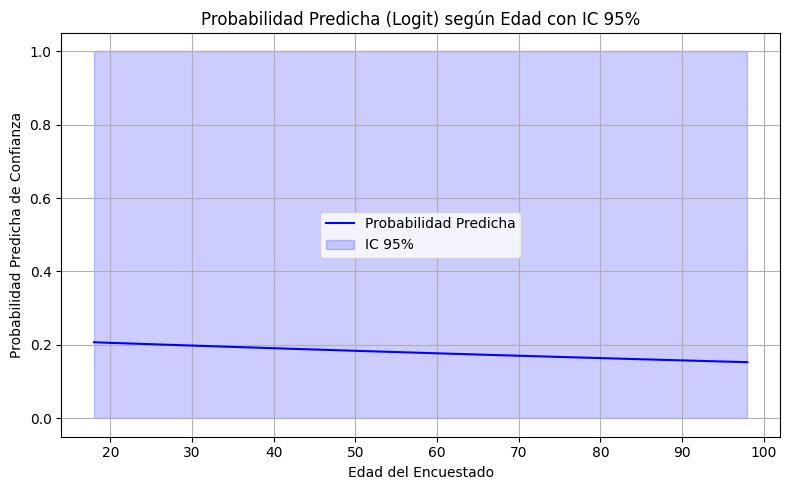

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos el rango de edad que queremos graficar
edad_range = np.linspace(data['edad'].min(), data['edad'].max(), 100)

# 2. Creamos un DataFrame falso donde todo se mantiene en su promedio,
X_mean = X.mean()
X_vals = pd.DataFrame([X_mean]*len(edad_range))
X_vals['edad'] = edad_range

# 3. Generamos las predicciones y sus intervalos de confianza
pred_results = logit_model.get_prediction(X_vals)
summary_frame = pred_results.summary_frame()

preds = summary_frame['predicted']
lower_bound = summary_frame['ci_lower']
upper_bound = summary_frame['ci_upper']

# 4. Graficar
plt.figure(figsize=(8, 5))
plt.plot(edad_range, preds, label="Probabilidad Predicha", color="b")
plt.fill_between(edad_range, lower_bound, upper_bound, color="b", alpha=0.2, label="IC 95%")
plt.xlabel("Edad del Encuestado")
plt.ylabel("Probabilidad Predicha de Confianza")
plt.title("Probabilidad Predicha (Logit) según Edad con IC 95%")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####Interpretación Logit (Efectos Marginales)

El cálculo de los Average Marginal Effects nos indica que hablar una lengua indígena disminuye la probabilidad de tener niveles altos de confianza en la Policía Nacional en un 11.53%, manteniendo todas las demás variables constantes (edad, sexo, educación y estrato socioeconómico). Este hallazgo es altamente estadísticamente significativo al 1% (p < 0.01).

Esta penalización de ~11.5% en la probabilidad de confiar en la autoridad puede explicarse por múltiples factores estructurales en el Perú:
1. La Policía Nacional del Perú, en gran parte de sus dependencias, no cuenta con personal bilingüe o un enfoque intercultural robusto. Esto dificulta que los ciudadanos con lengua materna indígena (quechua, aimara, lenguas amazónicas) puedan realizar denuncias o pedir ayuda en su propio idioma, generando una experiencia de exclusión institucional y desconfianza.
2. Históricamente, las poblaciones indígenas han sido grupos vulnerables frente a abusos de autoridad, discriminación estructural, y en muchos casos, han habitado en zonas con menor presencia protectora del Estado y mayor represión. Esto se traduce en una percepción de la policía como una entidad distante o punitiva en lugar de protectora.
3. Aunque el modelo controla por estrato socioeconómico y educación, hablar una lengua indígena suele intersectar con ubicaciones geográficas donde los servicios del Estado, incluyendo comisarías, son precarios, lentos o ineficaces, lo que merma la confianza institucional.

### Modelo Probit

In [ ]:
# Ajuste del modelo Probit
probit_model = sm.Probit(Y, X).fit()
print(probit_model.summary())


         Current function value: 0.482342
         Iterations: 35
                          Probit Regression Results                           
Dep. Variable:       conf_policia_dic   No. Observations:                 5046
Model:                         Probit   Df Residuals:                     5027
Method:                           MLE   Df Model:                           18
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.02074
Time:                        04:32:24   Log-Likelihood:                -2433.9
converged:                      False   LL-Null:                       -2485.4
Covariance Type:            nonrobust   LLR p-value:                 6.003e-14
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.9251      0.232     -3.983      0.000      -1.380      -0.470
lengua_indigena    -0.4188      0.053     -7.902  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Efectos Marginales para el modelo Probit
probit_margeff = probit_model.get_margeff(method="dydx", at="overall")
print(probit_margeff.summary())


       Probit Marginal Effects       
Dep. Variable:       conf_policia_dic
Method:                          dydx
At:                           overall
                     dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
lengua_indigena    -0.1128      0.014     -7.986      0.000      -0.141      -0.085
edad               -0.0007      0.000     -1.873      0.061      -0.001    3.24e-05
mujer               0.0058      0.011      0.513      0.608      -0.016       0.028
educ_2.0           -1.5184   1.81e+04   -8.4e-05      1.000   -3.54e+04    3.54e+04
educ_3.0           -0.0061      0.029     -0.208      0.835      -0.064       0.051
educ_4.0            0.0279      0.030      0.932      0.351      -0.031       0.087
educ_5.0            0.0099      0.032      0.311      0.756      -0.053       0.072
educ_6.0            0.0276      0.030      0.920      0.357      -0.031       0.086
educ_7.0

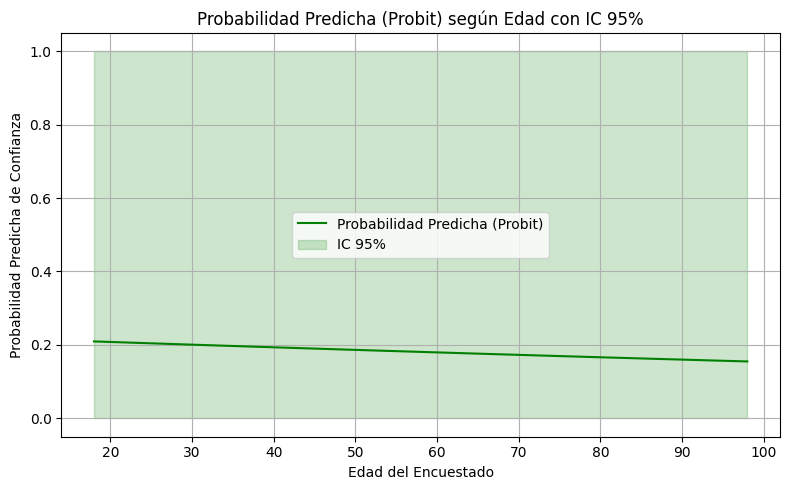

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

edad_range = np.linspace(data['edad'].min(), data['edad'].max(), 100)

X_mean = X.mean()
X_vals = pd.DataFrame([X_mean]*len(edad_range))
X_vals['edad'] = edad_range

pred_results_probit = probit_model.get_prediction(X_vals)
summary_frame_probit = pred_results_probit.summary_frame()

preds_probit = summary_frame_probit['predicted']
lower_bound_probit = summary_frame_probit['ci_lower']
upper_bound_probit = summary_frame_probit['ci_upper']

plt.figure(figsize=(8, 5))
plt.plot(edad_range, preds_probit, label="Probabilidad Predicha (Probit)", color="g")
plt.fill_between(edad_range, lower_bound_probit, upper_bound_probit, color="g", alpha=0.2, label="IC 95%")
plt.xlabel("Edad del Encuestado")
plt.ylabel("Probabilidad Predicha de Confianza")
plt.title("Probabilidad Predicha (Probit) según Edad con IC 95%")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretación Probit (Efectos Marginales)

De manera casi idéntica al modelo Logit, los resultados marginales del modelo Probit indican que hablar una lengua indígena reduce la probabilidad de tener alta confianza en la policía en un 11.28%. Este resultado también es estadísticamente significativo al 1% (p < 0.01).

La diferencia entre el -11.53% del Logit y el -11.28% del Probit es minúscula (apenas 0.25 puntos porcentuales). Esto ocurre porque ambos asumen distribuciones probabilísticas en forma de "S" (Logística vs. Normal Estándar) que son empíricamente indistinguibles en el centro de la distribución. La consistencia entre ambos modelos nos da robustez: sin importar el supuesto matemático exacto que usemos, la conclusión es contundente y el impacto negativo es real.

### Comparación entre el Modelo MCO y los Modelos Logit/Probit

Tanto el modelo de Mínimos Cuadrados Ordinarios (MCO) como los Modelos de Respuesta Binaria (Logit/Probit) llegan a la misma conclusión de fondo. Existe un efecto negativo y altamente significativo entre tener una lengua indígena y la confianza en la policía. Sin embargo, la forma en que miden este efecto es metodológicamente distinta.

1. Diferencia en la Variable Dependiente (Y):
*   El modelo MCO evaluó la confianza en su escala original del 1 al 4. El resultado de su regresión múltiple fue un coeficiente de -0.2256. Esto se interpreta como que hablar lengua indígena reduce el puntaje de confianza en aproximadamente un cuarto de punto (0.22) en esa escala, asumiendo saltos lineales entre "Nada" y "Poco", "Poco" y "Suficiente", etc.
*   Los modelos Logit y Probit Evalúan una variable binaria. El resultado transformado a Efectos Marginales arrojó un -11.5%. Esto se interpreta directamente en términos de probabilidades de ocurrencia: es un 11.5% menos probable que confíes en la policía si tu lengua materna es indígena.

Conclusión:
La similitud conceptual entre ambos frentes de trabajo demuestra una fuerte robustez estadística en el trabajo de investigación del equipo. La etnicidad/lengua materna es un predictor sociodemográfico claro de desconfianza institucional en el Perú.